In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate
from sklearn.preprocessing import StandardScaler

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../..')))
from utils.tools import (
    extract_clean_segments,
    compute_lagged_correlations,
    find_dominant_lagged_pairs,
    print_dominant_pairs,
    plot_pearson_heatmap,
    report_correlation_distribution,
    classify_anomalies,
    summarize,
    collect_seg_stats,
    plot_threshold_sensitivity,
    preceding_normal_context,
    max_z_score,
    compute_univariate_intensity,
    plot_univariate_intensity_distribution
)

For simplicity, we will use the preprocessed version the SWAN dataset provided by the authors of [CrossAD](https://github.com/decisionintelligence/CrossAD)

In [2]:
df = pd.read_csv("../../datasets/swan/SWAN.csv")

In [3]:
print(df.describe())

               date          data
count  4.680000e+06  4.680000e+06
mean   6.000050e+04 -1.079478e+23
std    3.464102e+04  1.270042e+24
min    1.000000e+00 -4.020000e+25
25%    3.000075e+04  0.000000e+00
50%    6.000050e+04  2.712515e+00
75%    9.000025e+04  1.216877e+02
max    1.200000e+05  8.100000e+25


In [4]:
labels_mask = df['cols'] == 'label'
labels_df = df[labels_mask][['date', 'data']].rename(columns={'data': 'label'}).reset_index(drop=True)
features_df = df[~labels_mask].copy()

features_pivot = features_df.pivot(index='date', columns='cols', values='data')
features_pivot = features_pivot.sort_index()
features_pivot.columns.name = None

n = len(features_pivot)
train_df = features_pivot.iloc[:n // 2].reset_index(drop=True)
test_df = features_pivot.iloc[n // 2:].reset_index(drop=True)
labels_df = labels_df.reset_index(drop=True)

print(f"Train: {len(train_df)} entries")
print(f"Test:  {len(test_df)} entries")

Train: 60000 entries
Test:  60000 entries


In [5]:
# Check if contains NaN values
nan_counts = df.isna().sum()
print("\nNaN counts per column:")
print(nan_counts)


NaN counts per column:
date    0
data    0
cols    0
dtype: int64


In [6]:
# Check if standardized/normalized
print("\nFeature value ranges:")
for col in features_pivot.columns:
    col_min = features_pivot[col].min()
    col_max = features_pivot[col].max()
    print(f"{col}: min={col_min:.3f}, max={col_max:.3f}")


Feature value ranges:
ABSNJZH: min=0.000, max=2924.976
BFLARE: min=0.000, max=1.000
CFLARE: min=0.000, max=2.000
CRLN_OBS: min=0.057, max=359.995
CRVAL1: min=-52.871, max=420.256
EPSX: min=-0.392, max=0.437
EPSY: min=-0.386, max=0.407
EPSZ: min=-0.938, max=0.938
IS_TMFI: min=0.000, max=1.000
LAT_MAX: min=-30.418, max=31.078
LAT_MIN: min=-32.765, max=27.186
LON_MAX: min=-68.688, max=91.519
LON_MIN: min=-87.592, max=69.540
MEANALP: min=-2.083, max=0.286
MEANGAM: min=13.560, max=81.087
MEANGBH: min=17.610, max=129.359
MEANGBT: min=25.825, max=231.574
MEANGBZ: min=27.784, max=247.126
MEANJZD: min=-9.359, max=10.047
MEANJZH: min=-0.066, max=0.066
MEANPOT: min=356.304, max=630307481.900
MEANSHR: min=9.424, max=60.418
MFLARE: min=0.000, max=1.000
QUALITY: min=0.000, max=84992.000
R_VALUE: min=0.000, max=5.655
SAVNCPP: min=0.000, max=108546000000000.000
SHRGT45: min=0.000, max=100.000
TOTBSQ: min=0.000, max=143192000000.000
TOTFX: min=-14799999999999997818961920.000, max=164999999999999983809

## Correlation Analysis

In [7]:
df = features_pivot.copy()
df['label'] = labels_df.set_index('date').loc[df.index, 'label'].values
df['label'] = df['label'].astype(int)
df = df.reset_index(drop=True)
X_full = df.drop(columns=['label']).values.astype(np.float64)
event = df['label'].values.astype(int)
N, C = X_full.shape
split = N // 2
normal_all = (event == 0)
feature_names = [c for c in df.columns if c != 'label']

Train total: 60000, normal: 51000, anomalies removed: 9000


/Users/marcp/.pyenv/versions/3.12.13/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/marcp/.pyenv/versions/3.12.13/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


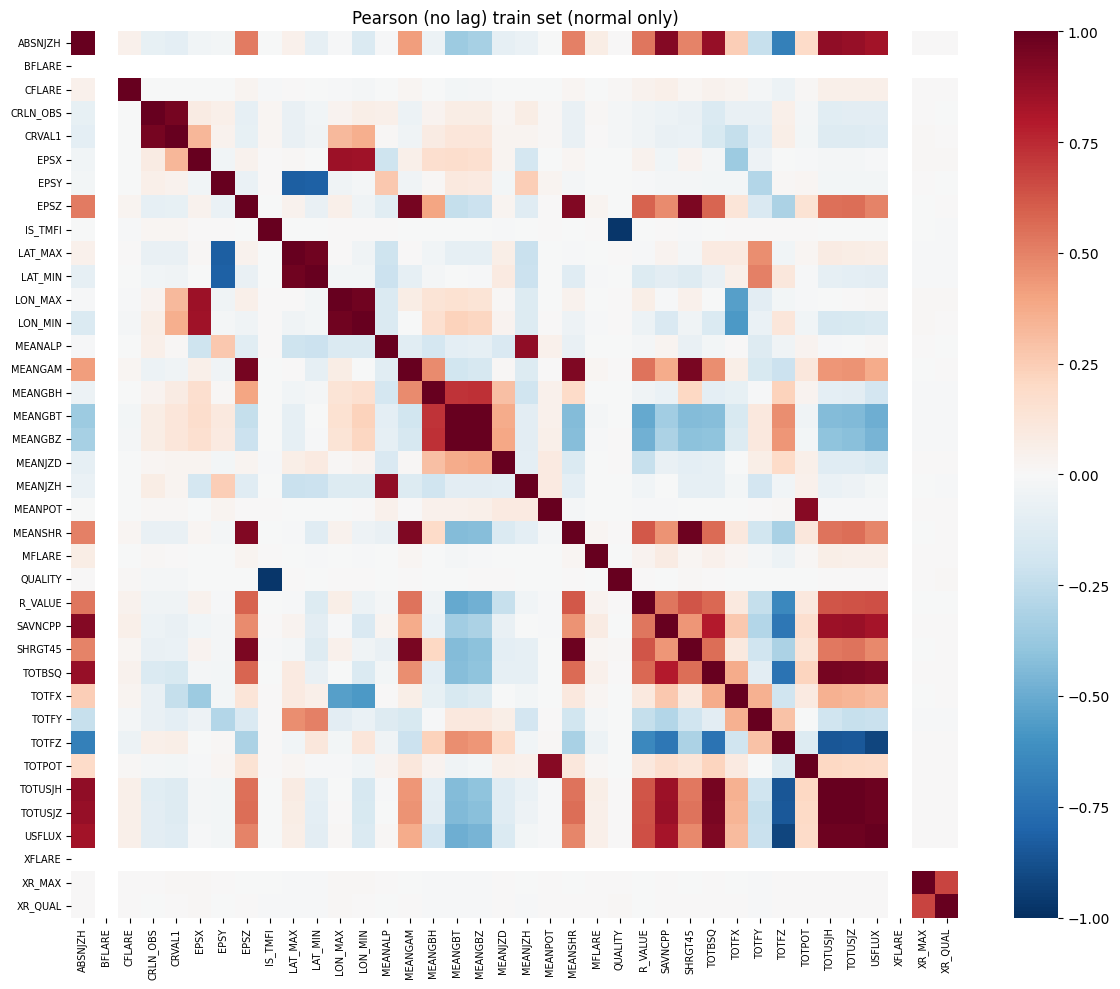

Total pairs: 630
  Pairs with |r| > 0.3: 117/630 (18.6%)
  Pairs with |r| > 0.5: 67/630 (10.6%)
  Pairs with |r| > 0.7: 39/630 (6.2%)


In [8]:
train_normal = X_full[:split][normal_all[:split]]
print(f"Train total: {split}, normal: {len(train_normal)}, anomalies removed: {split - len(train_normal)}")

pearson_matrix = np.corrcoef(train_normal, rowvar=False)
plot_pearson_heatmap(pearson_matrix, feature_names, title="Pearson (no lag) train set (normal only)", figsize=(12, 10), tick_fontsize=7)
report_correlation_distribution(pearson_matrix)

Blank lines/columns are channels which have a zero variance.

In [9]:
max_lag = 192

normal_train_mask = normal_all[:split]
features_array = X_full[:split]
segments = extract_clean_segments(features_array, normal_train_mask, max_lag=max_lag)
if not segments:
    raise ValueError(f"No clean segment with length >= {2 * max_lag}.")

seg_lengths = list(map(len, segments))
print(f"Segments (L >= {2 * max_lag}): {len(segments)} | min={min(seg_lengths)}, max={max(seg_lengths)}, total={sum(seg_lengths)}")

lagged_corrs = compute_lagged_correlations(segments, max_lag=max_lag)

Segments (L >= 384): 10 | min=410, max=3627, total=14667


Segments (Spearman): 100%|██████████| 10/10 [00:00<00:00, 24.17it/s]


In [10]:
pairs_info = find_dominant_lagged_pairs(lagged_corrs, max_lag=max_lag, threshold=0.5)
print("Pairs with dominant lagged correlation (|r(best_lag)| > 0.5 and > |r(0)|):")
print_dominant_pairs(pairs_info, feature_names=feature_names)

Pairs with dominant lagged correlation (|r(best_lag)| > 0.5 and > |r(0)|):
Total pairs: 295
CRLN_OBS - CRVAL1  : r(0)=+0.417  r(+10)=+0.419  [pearson]
  MFLARE - QUALITY : r(0)=-0.011  r(+156)=+0.404  [spearman]
 IS_TMFI - MFLARE  : r(0)=+0.016  r(-154)=-0.404  [pearson]
 MEANJZD - MFLARE  : r(0)=+0.052  r(-145)=-0.281  [pearson]
  MFLARE - TOTFY   : r(0)=-0.274  r(-8)=-0.275  [pearson]
 ABSNJZH - MFLARE  : r(0)=+0.260  r(+33)=+0.270  [pearson]
  MFLARE - SHRGT45 : r(0)=+0.265  r(-25)=+0.270  [pearson]
  MFLARE - TOTPOT  : r(0)=+0.267  r(-50)=+0.269  [pearson]
  MFLARE - TOTBSQ  : r(0)=+0.268  r(-50)=+0.269  [pearson]
 MEANSHR - MFLARE  : r(0)=+0.264  r(+25)=+0.267  [pearson]
  MFLARE - SAVNCPP : r(0)=+0.250  r(-33)=+0.267  [pearson]
  MFLARE - TOTUSJZ : r(0)=+0.265  r(-50)=+0.266  [pearson]
  MFLARE - USFLUX  : r(0)=+0.264  r(-33)=+0.265  [pearson]
  MFLARE - TOTUSJH : r(0)=+0.262  r(-25)=+0.264  [pearson]
  MFLARE - TOTFZ   : r(0)=-0.257  r(-8)=-0.262  [pearson]
 MEANGAM - MFLARE  : 

## Anomaly analysis

In [11]:
X_full = df.drop(columns=['label']).values.astype(np.float64)
event = df['label'].values.astype(int)
N, C = X_full.shape
split = N // 2

normal_all = (event == 0)
scaler = StandardScaler().fit(X_full[:split][normal_all[:split]])
X = scaler.transform(X_full)[split:]
ev = event[split:]

In [12]:
n_train = split
n_test = len(ev)
n_anom = int(ev.sum())
dim = X.shape[1]

print(f"Dimension: {dim}")
print(f"Train Size: {n_train}")
print(f"Test (labeled): {n_test}")
print(f"Anomaly Ratio (%): {100.0 * n_anom / n_test:.2f}")

Dimension: 38
Train Size: 60000
Test (labeled): 60000
Anomaly Ratio (%): 32.60


In [13]:
df_long, df_short = classify_anomalies(X, ev, pairs_info=pairs_info, short_min_size=30)
print(f"Anomalous segments: {len(df_long) + len(df_short)}")
summarize(df_long, df_short)

Anomalous segments: 6139
Counts per method (long segments):
+----------------------+-----------+------------+--------+
| label                |   pearson |   spearman |   dcor |
|----------------------+-----------+------------+--------|
| UNIVARIATE           |         0 |          0 |      0 |
| BOTH                 |         2 |          2 |      2 |
| CROSS-CHANNEL        |         0 |          0 |      0 |
| UNDETECTED           |         0 |          0 |      0 |
| INSUFFICIENT_CONTEXT |         0 |          0 |      0 |
+----------------------+-----------+------------+--------+

Counts (short segments, < min_len points):
+----------------------+---------+
| label                |   count |
|----------------------+---------|
| UNIVARIATE           |    5079 |
| UNDETECTED           |    1056 |
| INSUFFICIENT_CONTEXT |       2 |
+----------------------+---------+


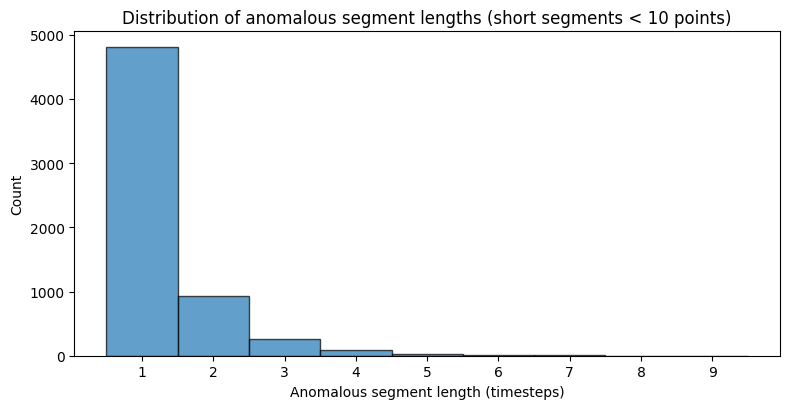

In [14]:
lengths = df_short['len'].astype(int)
bins = np.arange(lengths.min(), lengths.max() + 2) - 0.5

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=bins, edgecolor='black', alpha=0.7)
plt.xticks(np.arange(lengths.min(), lengths.max() + 1))
plt.xlabel("Anomalous segment length (timesteps)")
plt.ylabel("Count")
plt.tight_layout()
plt.title("Distribution of anomalous segment lengths (short segments < 10 points)")
plt.show()

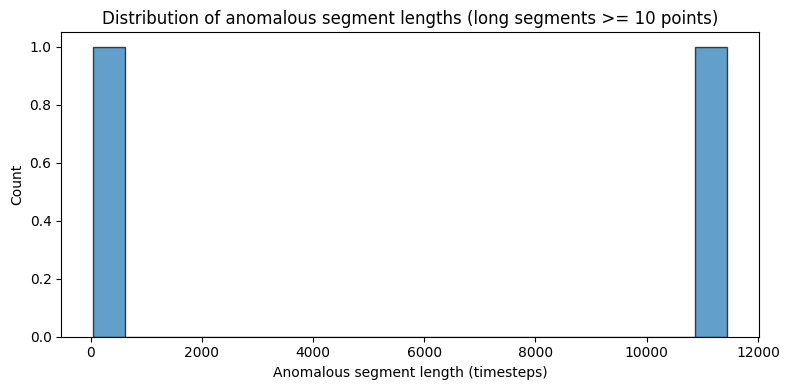

In [15]:
# Distribution of anomalous segment lengths (long segments >= 10 points)
plt.figure(figsize=(8, 4))
plt.hist(df_long['len'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel("Anomalous segment length (timesteps)")
plt.ylabel("Count")
plt.title("Distribution of anomalous segment lengths (long segments >= 10 points)")
plt.tight_layout()
plt.show()

max_z over 1056 UNDETECTED segments (short + long):
median: 2.14
90th percentile: 2.82
max: 2.99

Length stats over 1056 UNDETECTED segments:
min: 1
median: 1
max: 7


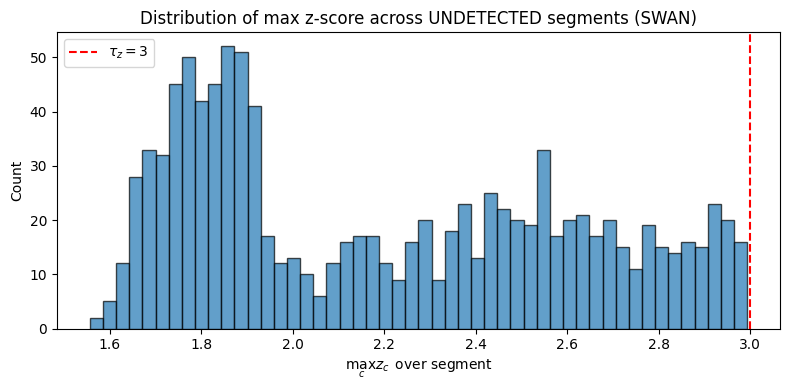

In [16]:
all_max_z = []
undetected_short = df_short[df_short['label'] == "UNDETECTED"]
undetected_long = df_long[df_long['lab_pearson'] == "UNDETECTED"]
undetected = pd.concat([undetected_short, undetected_long], ignore_index=True)

normal_test = (ev == 0)
for _, row in undetected.iterrows():
    s, e = int(row['start']), int(row['end'])
    ctx = preceding_normal_context(s, X, normal_test, min_size=30)
    if ctx is None:
        continue
    mz = max_z_score(X[s:e], ctx)
    all_max_z.append(mz)

all_max_z = np.array(all_max_z)
print(f"max_z over {len(all_max_z)} UNDETECTED segments (short + long):")
print(f"median: {np.median(all_max_z):.2f}")
print(f"90th percentile: {np.percentile(all_max_z, 90):.2f}")
print(f"max: {all_max_z.max():.2f}")

print(f"\nLength stats over {len(undetected)} UNDETECTED segments:")
print(f"min: {undetected['len'].min()}")
print(f"median: {int(undetected['len'].median())}")
print(f"max: {undetected['len'].max()}")

plt.figure(figsize=(8, 4))
plt.hist(all_max_z, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(3, color='red', ls='--', label=r'$\tau_z=3$')
plt.xlabel(r'$\max_c z_c$ over segment')
plt.ylabel("Count")
plt.title("Distribution of max z-score across UNDETECTED segments (SWAN)")
plt.legend()
plt.tight_layout()
plt.show()

## Sensibility Analysis

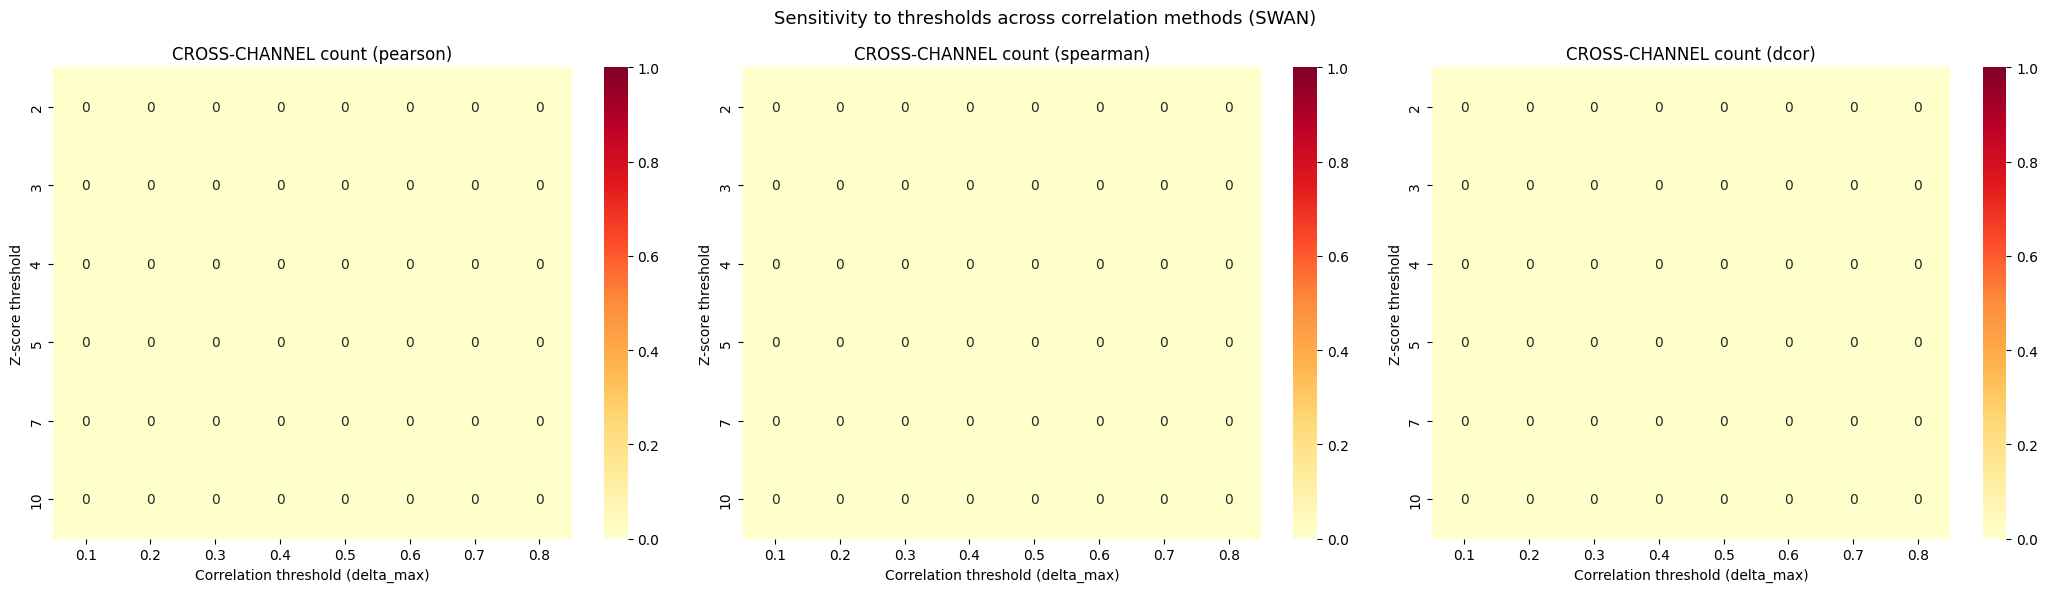

{'pearson': array([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0]]),
 'spearman': array([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0]]),
 'dcor': array([[0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0]])}

In [17]:
seg_stats = collect_seg_stats(X, ev, pairs_info=pairs_info)
plot_threshold_sensitivity(seg_stats, title="Sensitivity to thresholds across correlation methods (SWAN)")

In [18]:
intensity_df, summary = compute_univariate_intensity(
    test_arrays=[X], label_arrays=[ev], names=['swan'],
)
print(tabulate(summary, headers='keys', tablefmt='psql', floatfmt='.3f', showindex=False))

+--------------+------------------+--------------------+-----------------+
|   n_segments |   mean_ratio_uni |   median_ratio_uni |   min_ratio_uni |
|--------------+------------------+--------------------+-----------------|
|        2.000 |            1.000 |              1.000 |           1.000 |
+--------------+------------------+--------------------+-----------------+


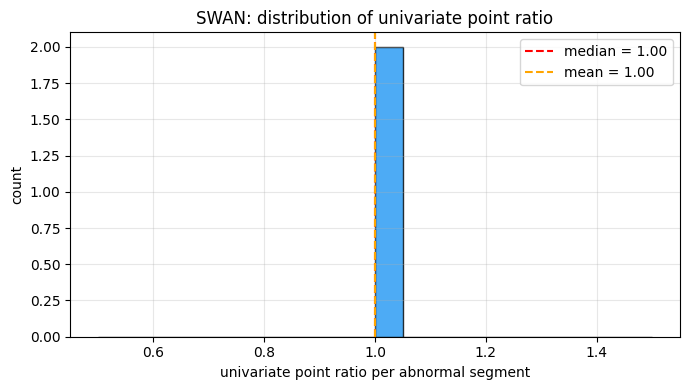

In [19]:
plot_univariate_intensity_distribution(intensity_df, 'SWAN')

Number of BOTH segments (union over pearson/spearman/dcor): 2
Anomalous points retained: 11487 / 19560 (58.7%)
+--------------+------------------+--------------------+-----------------+
|   n_segments |   mean_ratio_uni |   median_ratio_uni |   min_ratio_uni |
|--------------+------------------+--------------------+-----------------|
|        2.000 |            1.000 |              1.000 |           1.000 |
+--------------+------------------+--------------------+-----------------+


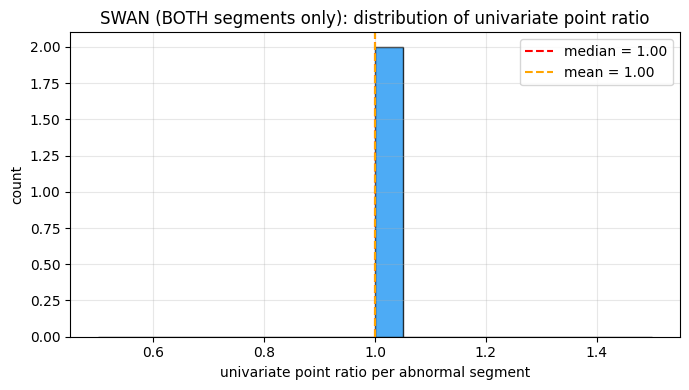

In [20]:
both_mask = (
    (df_long['lab_pearson'] == 'BOTH') |
    (df_long['lab_spearman'] == 'BOTH') |
    (df_long['lab_dcor'] == 'BOTH')
)
both_segments = df_long.loc[both_mask, ['start', 'end']].astype(int).values

ev_both = np.zeros_like(ev)
for s, e in both_segments:
    ev_both[s:e] = 1

print(f"Number of BOTH segments (union over pearson/spearman/dcor): {len(both_segments)}")
print(f"Anomalous points retained: {int(ev_both.sum())} / {int(ev.sum())} ({100.0 * ev_both.sum() / max(ev.sum(), 1):.1f}%)")

intensity_df_both, summary_both = compute_univariate_intensity(
    test_arrays=[X], label_arrays=[ev_both], names=['swan_both'],
)
print(tabulate(summary_both, headers='keys', tablefmt='psql', floatfmt='.3f', showindex=False))

plot_univariate_intensity_distribution(intensity_df_both, 'SWAN (BOTH segments only)')